In [1]:
#!pip install -U -q PyDrive
#!pip install auth

In [2]:
#from pydrive.auth import GoogleAuth
#from pydrive.drive import GoogleDrive
#from google.colab import auth
#from oauth2client.client import GoogleCredentials

# Authenticate and create the PyDrive client.
#auth.authenticate_user()
#gauth = GoogleAuth()
#gauth.credentials = GoogleCredentials.get_application_default()
#drive = GoogleDrive(gauth)

In [3]:
#pip install textblob
#!pip install wordcloud

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob

import pandas
print('pandas',pandas.__version__)
import numpy
print('numpy',numpy.__version__)
import glob
import seaborn as sns
import random
from scipy.fftpack import fft, ifft
from statsmodels.tsa.seasonal import seasonal_decompose

pandas 1.3.4
numpy 1.20.3


In [5]:
import wordcloud
from nltk.corpus import stopwords
import nltk
import string
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package stopwords to /Users/jwan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/jwan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /Users/jwan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/jwan/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [6]:
#john wan added this

df = pd.read_csv('Amazon_Unlocked_Mobile.csv')

In [7]:
df.head(10)

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0
5,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,1,I already had a phone with problems... I know ...,1.0
6,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,2,The charging port was loose. I got that solder...,0.0
7,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,2,"Phone looks good but wouldn't stay charged, ha...",0.0
8,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I originally was using the Samsung S2 Galaxy f...,0.0
9,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,3,It's battery life is great. It's very responsi...,0.0


In [8]:
df.tail(5)

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
413835,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,another great deal great price,0.0
413836,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,3,Ok,0.0
413837,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,Passes every drop test onto porcelain tile!,0.0
413838,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,3,I returned it because it did not meet my needs...,0.0
413839,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,4,Only downside is that apparently Verizon no lo...,0.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413840 entries, 0 to 413839
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Product Name  413840 non-null  object 
 1   Brand Name    348669 non-null  object 
 2   Price         407907 non-null  float64
 3   Rating        413840 non-null  int64  
 4   Reviews       413778 non-null  object 
 5   Review Votes  401544 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 18.9+ MB


The next fuction “isna().sum() “ checks for missing values within the dataset. As you can see, there are no product names and ratings that are missing, but for brand name, price, reviews, and votes are missing quite a bit of values.

In [10]:
#Checks for Missing values
#Reference: https://towardsdatascience.com/handling-missing-values-with-pandas-b876bf6f008f#:~:text=result%20is%20True.-,df.,missing%20values%20in%20each%20column.
df.isna().sum()

Product Name        0
Brand Name      65171
Price            5933
Rating              0
Reviews            62
Review Votes    12296
dtype: int64

The shape function displays the number of rows and columns within the dataset.

In [11]:
df.shape

(413840, 6)

Cleaning and Preprocessing the data

The stop-word function’s purpose was to skim over the dataset and remove stop-words which are to iterate “a”, “the”, “is”, and “are” etc. This would result in accurate results for displaying data.

I also used the function “.join(x.lower()” to make all letters into lowercase letters.

In [12]:
stop_words = stopwords.words('english')

In [13]:
df = df[df['Reviews'].notnull()]

In [14]:
#Words into Lowercase and remove stopwords
#Reference: https://github.com/EnesGokceDS/Amazon_Reviews_NLP_Capstone_Project/blob/master/1_Data_cleaning_and_feature_extraction.ipynb
df['Reviews']=df['Reviews'].apply(lambda x: " ".join(x.lower() for x in x.split() if x not in stop_words))
df['Reviews'].head(5)

0    i feel lucky found used (phone us & used hard ...
1    nice phone, nice grade pantach revue. very cle...
2                                         very pleased
3    it works good goes slow sometimes good phone i...
4    great phone replace lost phone. the thing volu...
Name: Reviews, dtype: object

The next function “str.replace” deletes the punctuation marks found. I would then display the top 5 entries that the command did change the data.

In [15]:
#Deletes punctuation
#Reference: https://pandas.pydata.org/docs/reference/api/pandas.Series.str.replace.html
df['Reviews']=df['Reviews'].str.replace('[^\w\s]','')
df['Reviews'].head(5)

/var/folders/ch/bbrfdl9d6j7159f5vlmtq4z80000gp/T/ipykernel_10386/4045536589.py:3: FutureWarning: The default value of regex will change from True to False in a future version.
  df['Reviews']=df['Reviews'].str.replace('[^\w\s]','')


0    i feel lucky found used phone us  used hard al...
1    nice phone nice grade pantach revue very clean...
2                                         very pleased
3    it works good goes slow sometimes good phone i...
4    great phone replace lost phone the thing volum...
Name: Reviews, dtype: object

This function would count the number of words found in the reviews. Then I would display the top 5 entries that the number of words were accounted for.

In [16]:
#Count the number of words in Reviews
#Reference: https://towardsdatascience.com/9-functions-that-make-natural-language-pre-processing-a-piece-of-cake-8b885c151955
df['number_words']=[len(x.split()) for x in df['Reviews'].tolist()]
df.head(5)

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes,number_words
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,i feel lucky found used phone us used hard al...,1.0,42
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,nice phone nice grade pantach revue very clean...,0.0,26
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,very pleased,0.0,2
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,it works good goes slow sometimes good phone i...,0.0,10
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,great phone replace lost phone the thing volum...,0.0,23


Analysis of the Ratings

In [17]:
df['Rating'].unique()

array([5, 4, 1, 2, 3])

I began by using a histogram to display the Ratings for each review found using a scale from 1 through 5. As you can see there are more 5-star reviews than others by customers that are more satisfied with their products, but the next largest number of reviews would be the one-star reviews which would represent customers not satisfied with their products.

Text(0.5, 1.0, 'Ratings')

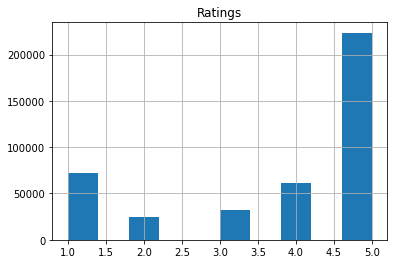

In [18]:
df['Rating'].hist(bins=10)
plt.title("Ratings")

The model below displays the correlation of all the mobile phone prices that are rated 5 stars. My initial idea to display the correlation between the product and price was to display all prices without the clutter of the Product Name as shown on the graph below. I'll still continue to work on this graph but as for now there's some progress done.

<AxesSubplot:xlabel='Review Votes', ylabel='Price'>

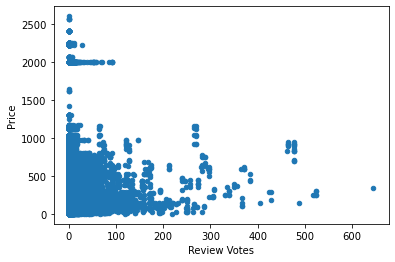

In [19]:
df.plot.scatter(y='Price', x=5)

Relationship between price and number of reviews

The next graph that would be presented would be a scatter plot that shows the correlation between each product and their respective price tag. There are over 400,000 reviews so the product name category would be cluttered.
As you can see, most of the products are located with a price under $750 which was to be expected for the price of a phone.

Updated Scatterplot

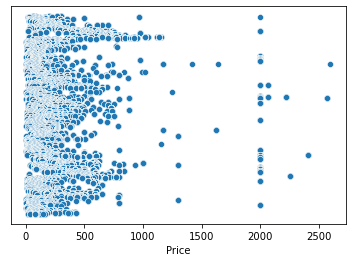

In [20]:
sns.scatterplot(data=df, x="Price", y= "Product Name")

ay = plt.gca()

ay.get_yaxis().set_visible(False)

Histogram displaying the amount of ratings in each category

The last graph that I would be presenting would be a subplot graph that displays the number of characters in reviews. Each subplot would display each rating from 1 through 5 with the number of characters are found. From what I was about to gather, each graph would contain mostly less that 250 characters in their reviews. Then I would include a graph containing the length of all reviews.

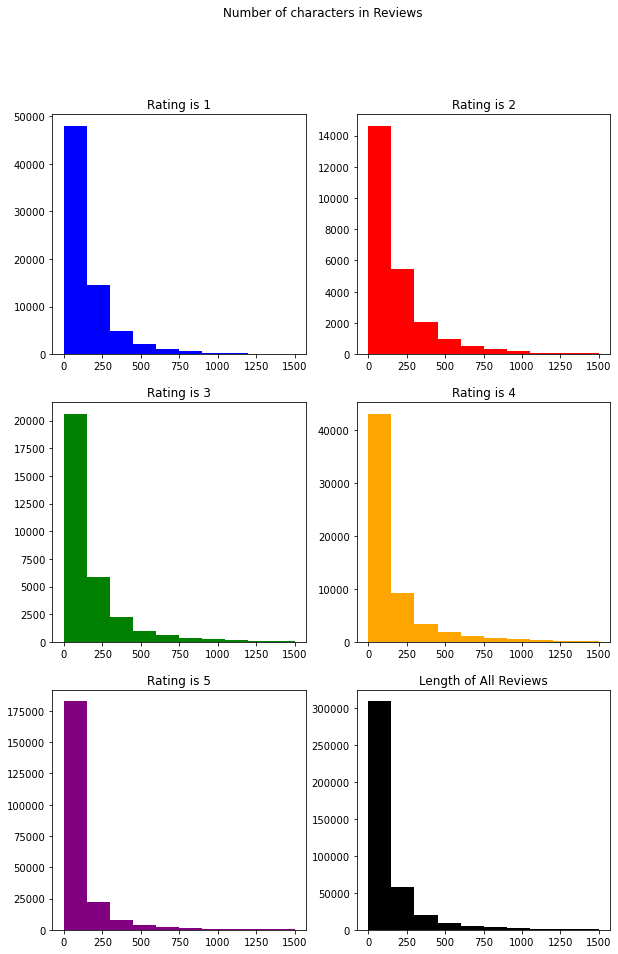

In [21]:
fig, axs = plt.subplots(3,2, figsize=(10, 15))

#Score 1
review_len = df.loc[df['Rating']==1]['Reviews'].str.len()
axs[0,0].hist(review_len, color='blue', range=(0,1500))
axs[0,0].set_title('Rating is 1')

#Score 2
review_len = df.loc[df['Rating']==2]['Reviews'].str.len()
axs[0,1].hist(review_len, color='red',range=(0,1500))
axs[0,1].set_title('Rating is 2')

#Score 3
review_len = df.loc[df['Rating']==3]['Reviews'].str.len()
axs[1,0].hist(review_len, color='green', range=(0,1500))
axs[1,0].set_title('Rating is 3')

#Score 4
review_len = df.loc[df['Rating']==4]['Reviews'].str.len()
axs[1,1].hist(review_len, color='orange', range=(0,1500))
axs[1,1].set_title('Rating is 4')


#Score 5
review_len = df.loc[df['Rating']==5]['Reviews'].str.len()
axs[2,0].hist(review_len, color='purple', range=(0,1500))
axs[2,0].set_title('Rating is 5')

#All Scores
review_len = df['Reviews'].str.len()
axs[2,1].hist(review_len, color='black', range=(0,1500))
axs[2,1].set_title('Length of All Reviews')


fig.suptitle('Number of characters in Reviews')

plt.show()

Project 2 Notebook April 9, 2022

In [22]:
#https://stackoverflow.com/questions/48590268/pandas-get-the-most-frequent-values-of-a-column
#The function below identifies the top three most chosen brands under the brand column. The brands that would be picked and tested are Samsung, BLU, and Apple.
n = 3
df['Brand Name'].value_counts()[:n].index.tolist()

['Samsung', 'BLU', 'Apple']

Text(0.5, 1.0, 'Top 3 Mobile Brands present')

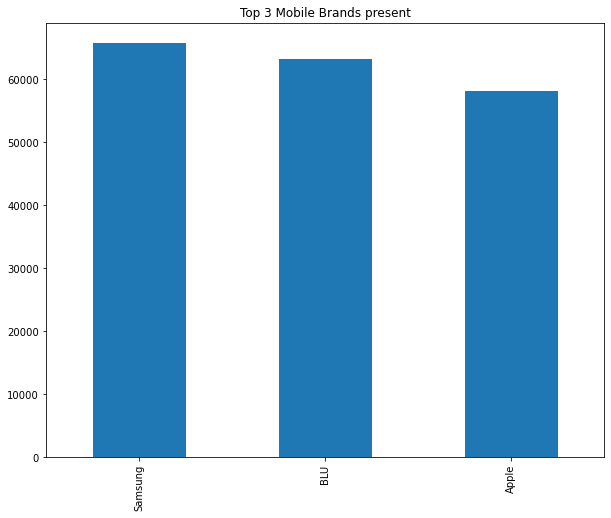

In [23]:
#https://www.analyticsvidhya.com/blog/2021/08/understanding-bar-plots-in-python-beginners-guide-to-data-visualization/
#The function below displays the data in a bar plot of the 3 most chosen brands.
top_3 = df['Brand Name'].value_counts()[:3]
top_3.plot(kind='bar',figsize=(10,8))
plt.title('Top 3 Mobile Brands present')

Text(0.5, 1.0, 'Prices of all Mobile Phones')

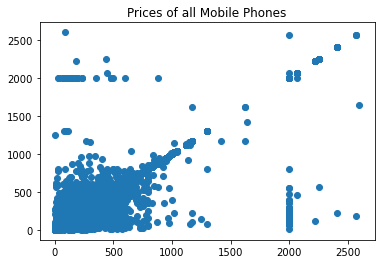

In [24]:
#I wanted to start off the next steps of the project by presenting the prices of all mobile phones. Below is the plot that displays the prices.
pandas.plotting.lag_plot(df['Price']);
plt.xlabel('')
plt.ylabel('')
plt.title('Prices of all Mobile Phones')

In [25]:
#https://www.marsja.se/python-pandas-groupby-tutorial-examples/ (group by function)
#By using a groupby function, I was able to create selected groups in the dataset which is presented below.
df_brand = df.groupby("Brand Name")
type(df_brand)

pandas.core.groupby.generic.DataFrameGroupBy

In [26]:
df_brand.groups

{'AKUA': [1576, 1577, 1578, 1579], 'AMM Global Enterprises': [301362, 301363, 301364, 301365, 301366, 301367, 301368, 301369, 301370], 'ARGOM TECH': [80051, 80052], 'ASUS': [80078, 80927, 80928, 80929, 80930, 80931, 80932, 80933, 80934, 80935, 80936, 80937, 80938, 80939, 80940, 80941, 80942, 80943, 80944, 80945, 80946, 80947, 80948, 80949, 80950, 80951, 80952, 80953, 80954, 80955, 80956, 80957, 80981, 80982, 80983, 80984, 80985, 80986, 80987, 81915, 81916, 81917, 81918, 81919, 81920, 81921, 81922, 81923, 81924, 81925, 81926, 81927, 81928, 81929, 81930, 81931, 81932, 81933, 81934, 81935, 81936, 81937, 81938, 81939, 81940, 81941, 81942, 81943, 81944, 81945, 81946, 81947, 81948, 81949, 81950, 81951, 81952, 81953, 81954, 81955, 81956, 81957, 81958, 81959, 81960, 81961, 81962, 81963, 81964, 81965, 81966, 81967, 81968, 81969, 81970, 81971, 81972, 81973, 81974, 81975, ...], 'ASUS Computers': [80208, 80209, 80210, 80211, 80212, 80213, 80214, 80215, 80216, 80217, 80218, 80219, 80220, 80221, 802

In [27]:
#The brand Samsung is the most common brand found and is the brand that is selected to display all Samsung details.
df_brand.get_group("Samsung")

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes,number_words
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,i feel lucky found used phone us used hard al...,1.0,42
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,nice phone nice grade pantach revue very clean...,0.0,26
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,very pleased,0.0,2
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,it works good goes slow sometimes good phone i...,0.0,10
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,great phone replace lost phone the thing volum...,0.0,23
...,...,...,...,...,...,...,...
413835,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,another great deal great price,0.0,5
413836,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,3,ok,0.0,1
413837,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,passes every drop test onto porcelain tile,0.0,7
413838,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,3,i returned meet needs seemed good selection ot...,0.0,8


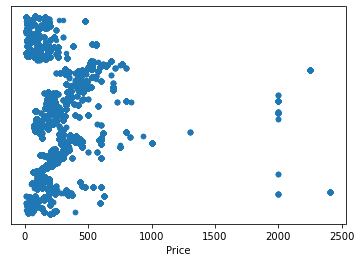

In [28]:
#https://www.statology.org/matplotlib-hide-axis/
#The following function gathers the grouped column "Samsung" in this case to display all prices within the group. The results can be found below.
df_brand.get_group("Samsung").plot.scatter(x='Price', y='Product Name')

#get current axes
ay = plt.gca()

#hide x-axis
ay.get_yaxis().set_visible(False)

In [29]:
#https://statisticsglobe.com/calculate-mean-group-python
#Finding the mean for all prices for all mobile phones under Samsung.

df_brand.get_group("Samsung")['Price'].mean()

291.7778580247901

In [30]:
#The brand BLU is the most common brand found and is the brand that is selected to display all BLU details.
df_brand.get_group("BLU")

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes,number_words
103014,BLU Advance 4.0- Includes One Month Free Servi...,BLU,75.00,2,i bought phone may completely stopped function...,0.0,135
103015,BLU Advance 4.0- Includes One Month Free Servi...,BLU,75.00,5,excellent,0.0,1
103016,BLU Advance 4.0- Includes One Month Free Servi...,BLU,75.00,5,great phone,0.0,2
103017,BLU Advance 4.0- Includes One Month Free Servi...,BLU,75.00,5,the screen small works great it faster samsung...,0.0,17
103018,BLU Advance 4.0- Includes One Month Free Servi...,BLU,75.00,2,need get rid phoneoverheat problem quite nice ...,0.0,10
...,...,...,...,...,...,...,...
410461,"VIVO IV Full HD Super Amoled,13MP,(16GB+2GBRAM...",BLU,209.99,3,this best phone i far i samsung htc lg etc my...,NaN,87
410462,"VIVO IV Full HD Super Amoled,13MP,(16GB+2GBRAM...",BLU,209.99,1,i left phone charger one day i went work forgo...,3.0,54
410463,"VIVO IV Full HD Super Amoled,13MP,(16GB+2GBRAM...",BLU,209.99,5,been using phone little month now i must say w...,2.0,31
410464,"VIVO IV Full HD Super Amoled,13MP,(16GB+2GBRAM...",BLU,209.99,1,im venezuela i made purchase live telephone iv...,11.0,41


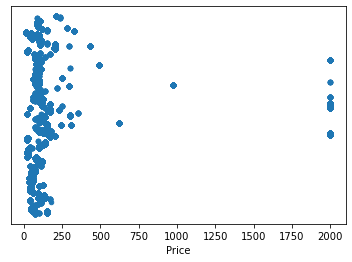

In [31]:
#https://www.statology.org/matplotlib-hide-axis/
df_brand.get_group("BLU").plot.scatter(x='Price', y='Product Name')

#get current axes
ay = plt.gca()

#hide x-axis
ay.get_yaxis().set_visible(False)

In [32]:
#Finding the mean for all prices for all mobile phones under BLU.

df_brand.get_group("BLU")['Price'].mean()

245.40926731707242

In [33]:
#The brand Apple is the most common brand found and is the brand that is selected to display all Apple details.
df_brand.get_group("Apple")

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes,number_words
3081,Apple - Iphone 5c A1532 Verizon 16 GB Cell Pho...,Apple,33.0,5,was gift husband loves it replaced first gen d...,5.0,30
3082,Apple - Iphone 5c A1532 Verizon 16 GB Cell Pho...,Apple,33.0,5,great price extremely fast shipping works adve...,1.0,7
3083,Apple - Iphone 5c A1532 Verizon 16 GB Cell Pho...,Apple,33.0,4,moving android applemy kids phone keep straigh...,1.0,37
3084,Apple - Iphone 5c A1532 Verizon 16 GB Cell Pho...,Apple,33.0,4,it compatible verizon not pink peach pretty be...,0.0,20
3085,Apple - Iphone 5c A1532 Verizon 16 GB Cell Pho...,Apple,33.0,5,i love phone thank much,1.0,5
...,...,...,...,...,...,...,...
410273,Virgin Mobile iPhone 5 Black,Apple,289.0,5,it came new item no scratches works perfect,1.0,8
410274,Virgin Mobile iPhone 5 Black,Apple,289.0,1,in fact phone could activated virgin mobile gr...,1.0,31
410275,Virgin Mobile iPhone 5 Black,Apple,289.0,5,nice phone,0.0,2
410276,Virgin Mobile iPhone 5 Black,Apple,289.0,2,why is this iphone locked and only came with ...,4.0,29


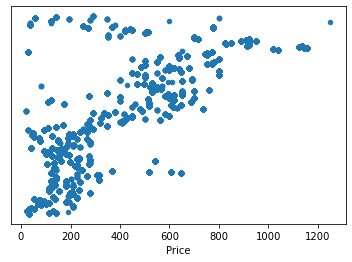

In [34]:
#https://www.statology.org/matplotlib-hide-axis/
df_brand.get_group("Apple").plot.scatter(x='Price', y='Product Name')

#get current axes
ay = plt.gca()

#hide x-axis
ay.get_yaxis().set_visible(False)

In [35]:
#Finding the mean for all prices for all mobile phones under Apple.

df_brand.get_group("Apple")['Price'].mean()

306.3019355449361